In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df=pd.read_csv('Social_Network_Ads.csv')

In [24]:
df=df.iloc[:,2:]

In [25]:
df.sample(5)

,Age,EstimatedSalary,Purchased
325,41,60000,0
379,58,23000,1
0,19,19000,0
171,34,115000,0
40,27,17000,0


## Train tesr split

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop('Purchased', axis=1),
                                                df['Purchased'],
                                                test_size=0.3,
                                                random_state=0)
X_train.shape, X_test.shape

((280, 2), (120, 2))

## Standardscaler

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transfer train and rest sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [28]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [29]:
X_train_scaled =  pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled =  pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [30]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [31]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effects of scalling

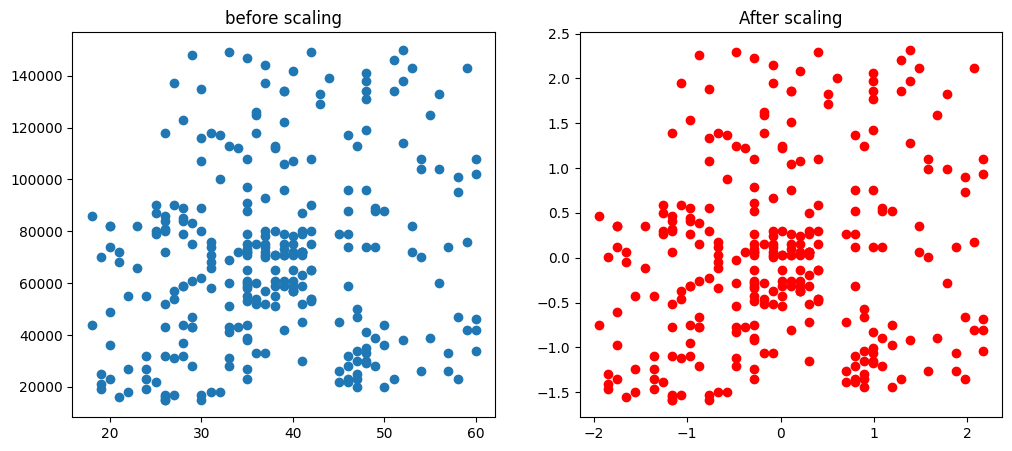

In [29]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("before scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After scaling")
plt.show()

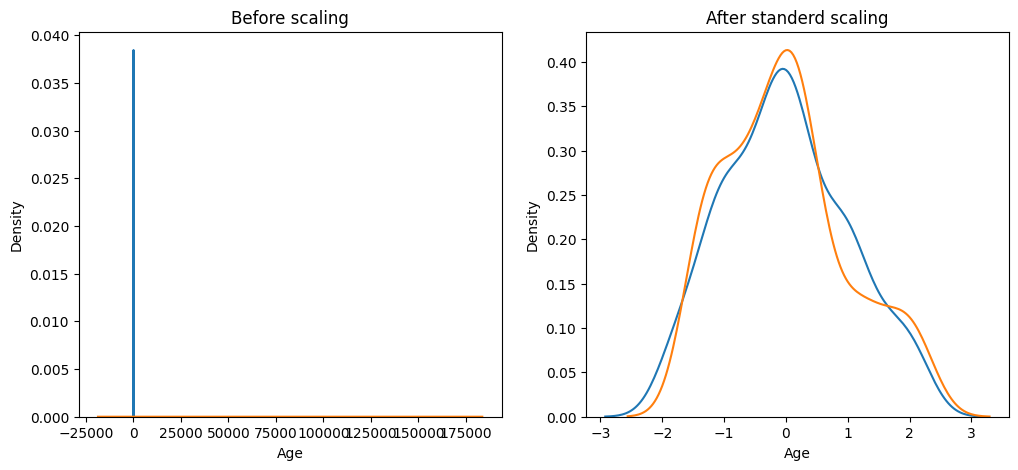

In [30]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
# Before scaling
ax1.set_title("Before scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#After ploting
ax2.set_title("After standerd scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

## Comparision of Distributions

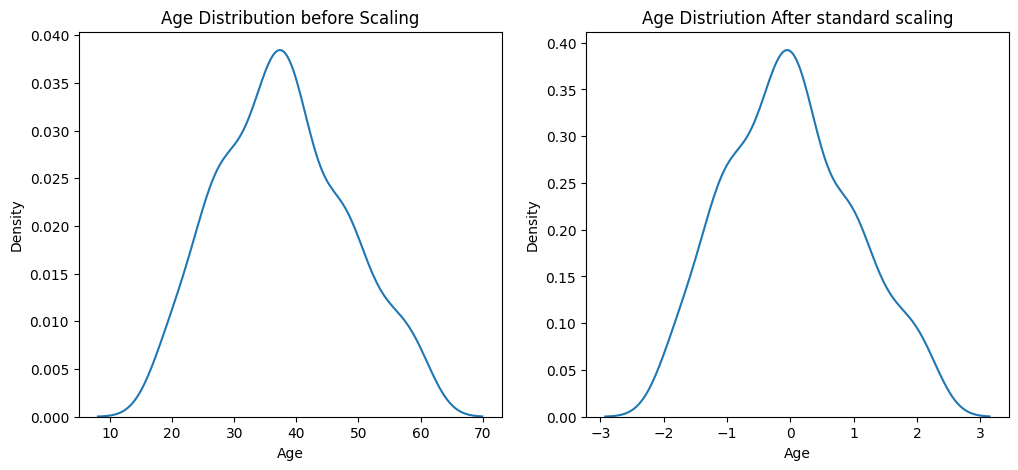

In [32]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
# Before scaling
ax1.set_title('Age Distribution before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# After scaling
ax2.set_title('Age Distriution After standard scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

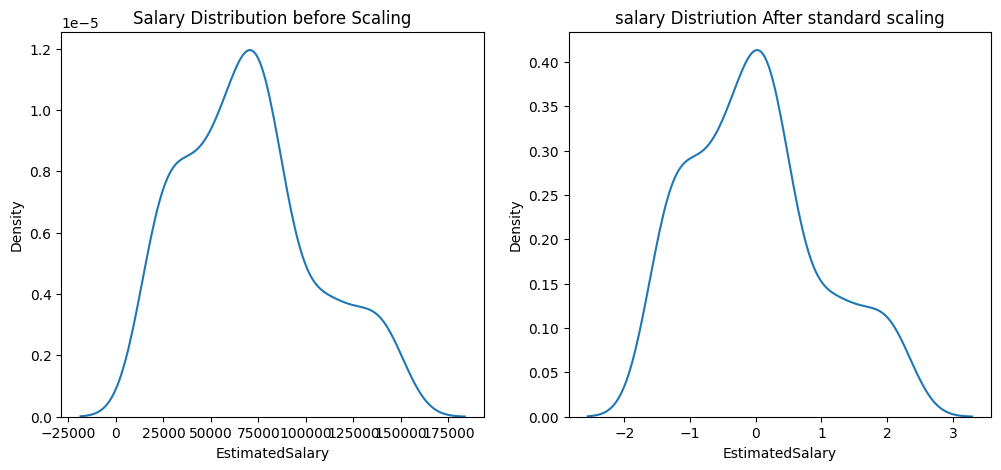

In [34]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
# Before scaling
ax1.set_title('Salary Distribution before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# After scaling
ax2.set_title('salary Distriution After standard scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

## Why Scaling is important

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [40]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
Y_pred = lr.predict(X_test)
Y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [42]:
from sklearn.metrics import accuracy_score

In [44]:
print("Actual",accuracy_score(Y_test,Y_pred))
print("Scaled",accuracy_score(Y_test,Y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [45]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Effect of outlier

In [49]:
df = pd.concat(
    [df, pd.DataFrame({
        'Age':[5,90,95],
        'EstimatedSalary':[1000,250000,350000],
        'Purchased':[0,1,1]
    })],
    ignore_index=True
)

In [50]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


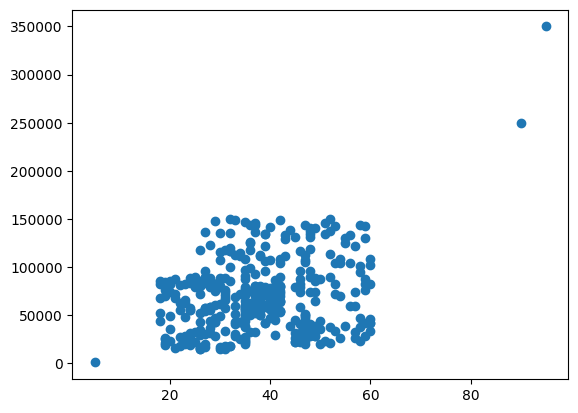

In [51]:
plt.scatter(df['Age'],df['EstimatedSalary'])